In [3]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import tifffile
import os

# --- Load 4D TIFF Stack ---
tiff_path = r"./bead_visualization_5frame_newzach/1um/100fr/data/beads1um_stack_1p6Vscan_neg0p17offset_5fileSum_4D_100fr_hyper.tif"  # Update this path

# Load the stack
stack = tifffile.imread(tiff_path)

In [4]:
# Check shape and dtype
print(f"Shape: {stack.shape}")   # e.g. (T, Z, Y, X)
print(f"Dtype: {stack.dtype}")
print(f"Min: {stack.min()}, Max: {stack.max()}")

Shape: (30, 21, 256, 256)
Dtype: float32
Min: 0.0, Max: 134.67999267578125


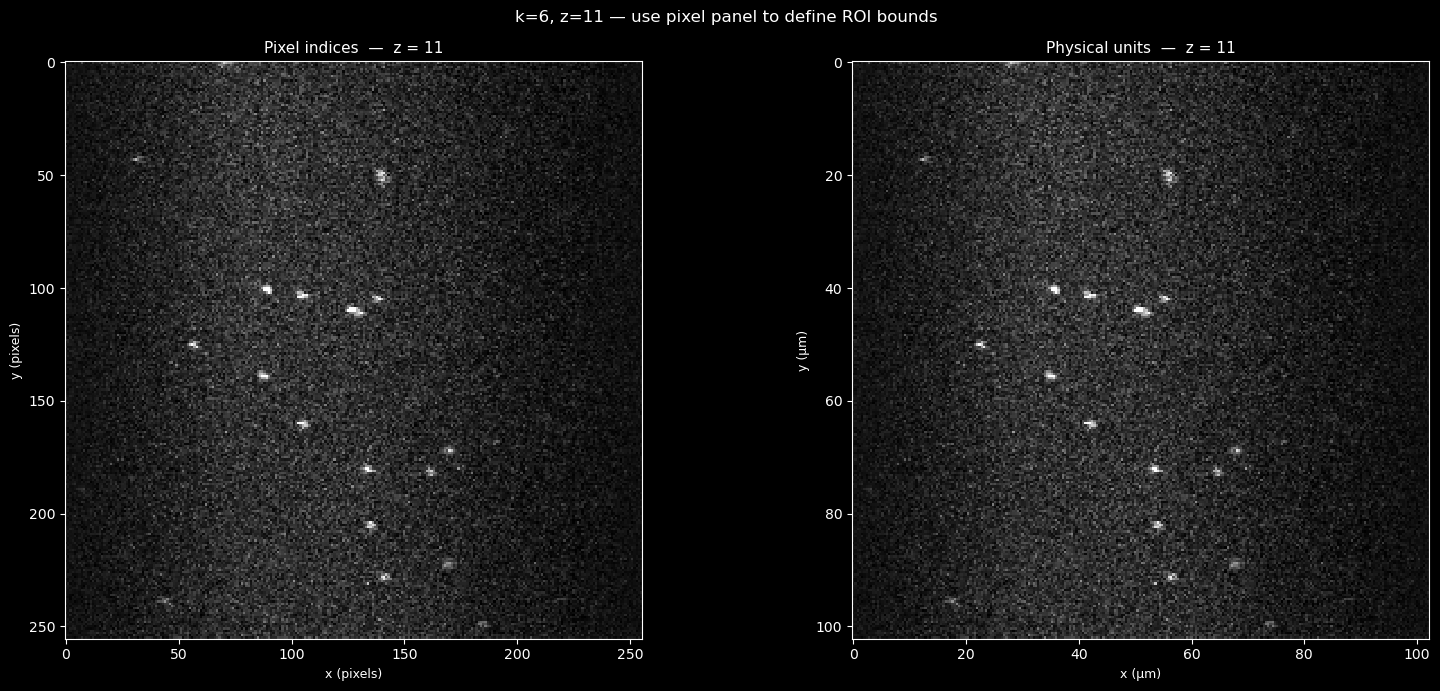

In [5]:
# inspect beads at unique 'z' and 't' to determine ROIs
import numpy as np
import matplotlib.pyplot as plt

# ══════════════════════════════════════════════════════════════════════════════
# EDIT THESE
# ══════════════════════════════════════════════════════════════════════════════
k      = 6   # time point
z_idx  = 11  # z plane to inspect
xy_spacing = 0.4
z_spacing  = 1.0
# ══════════════════════════════════════════════════════════════════════════════

nz, ny, nx = stack[k].shape
vmin, vmax = np.percentile(stack[k], 1), np.percentile(stack[k], 99.99)

fig, axes = plt.subplots(1, 2, figsize=(16, 7), facecolor='black')

# ── Left: pixel indices ───────────────────────────────────────────────────────
ax = axes[0]
ax.pcolormesh(np.arange(nx), np.arange(ny), stack[k, z_idx, :, :],
              cmap='gray', vmin=vmin, vmax=vmax)
ax.invert_yaxis()
ax.set_aspect('equal')
ax.set_facecolor('black')
ax.tick_params(colors='white')
ax.set_xlabel('x (pixels)', color='white', fontsize=9)
ax.set_ylabel('y (pixels)', color='white', fontsize=9)
ax.set_title(f'Pixel indices  —  z = {z_idx}', color='white', fontsize=11)
for sp in ax.spines.values(): sp.set_edgecolor('white')

# ── Right: physical units ─────────────────────────────────────────────────────
x_ax = np.arange(nx) * xy_spacing
y_ax = np.arange(ny) * xy_spacing
ax = axes[1]
ax.pcolormesh(x_ax, y_ax, stack[k, z_idx, :, :],
              cmap='gray', vmin=vmin, vmax=vmax)
ax.invert_yaxis()
ax.set_aspect('equal')
ax.set_facecolor('black')
ax.tick_params(colors='white')
ax.set_xlabel('x (µm)', color='white', fontsize=9)
ax.set_ylabel('y (µm)', color='white', fontsize=9)
ax.set_title(f'Physical units  —  z = {z_idx}', color='white', fontsize=11)
for sp in ax.spines.values(): sp.set_edgecolor('white')

fig.suptitle(f'k={k}, z={z_idx} — use pixel panel to define ROI bounds',
             color='white', fontsize=12)
plt.tight_layout()
plt.savefig('bead_field_inspect.png', dpi=200, bbox_inches='tight', facecolor='black')
plt.show()

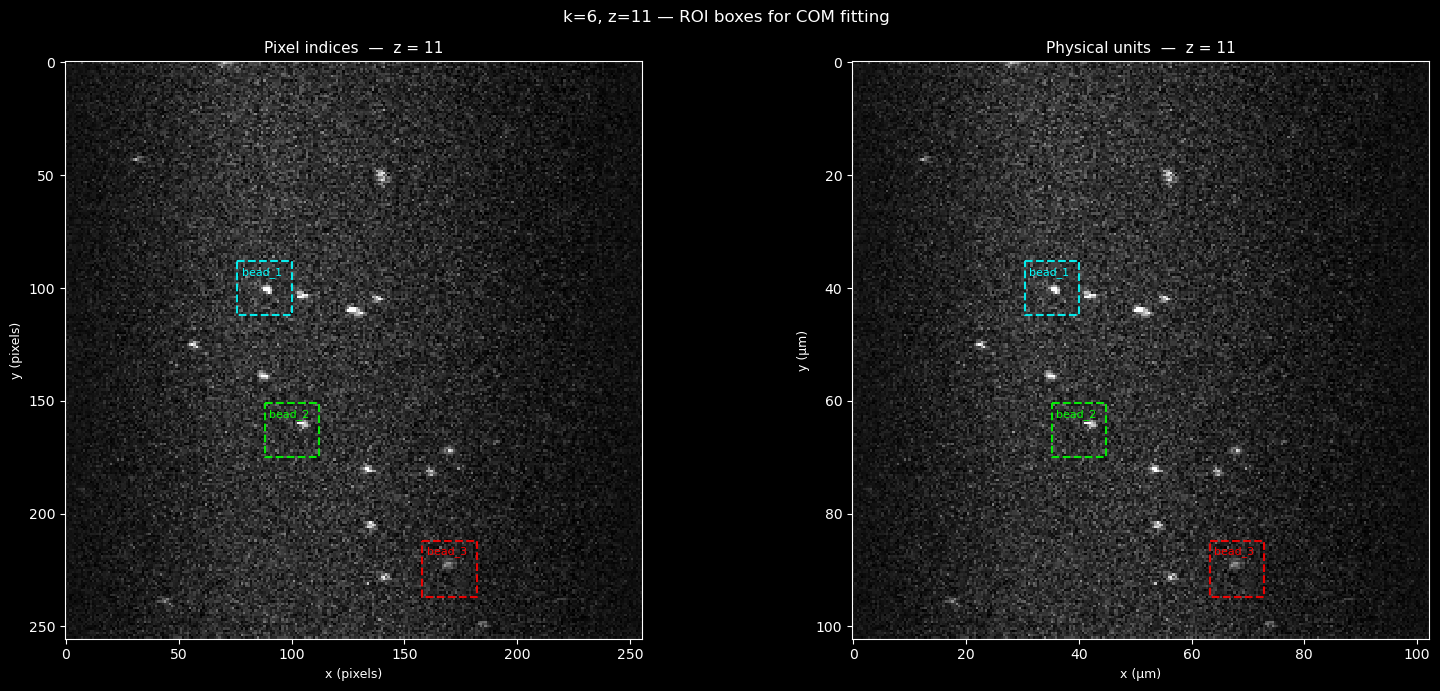

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Determine ROIs, and save reference image 

# ══════════════════════════════════════════════════════════════════════════════
# EDIT THESE
# ══════════════════════════════════════════════════════════════════════════════
k      = 6
z_idx  = 11
xy_spacing = 0.4
z_spacing  = 1.0

# Define ROI for each bead as (x_min, x_max, y_min, y_max) in PIXELS
beads = {
    'bead_1': {'roi': (76, 100, 88, 112)},
    'bead_2': {'roi': (88, 112, 151, 175)},
    'bead_3': {'roi': (158, 182, 212, 237)},
}
# ══════════════════════════════════════════════════════════════════════════════

nz, ny, nx = stack[k].shape
vmin, vmax = np.percentile(stack[k], 1), np.percentile(stack[k], 99.99)
colors = ['cyan', 'lime', 'red', 'yellow', 'magenta']

fig, axes = plt.subplots(1, 2, figsize=(16, 7), facecolor='black')

# ── Left: pixel indices ───────────────────────────────────────────────────────
ax = axes[0]
ax.pcolormesh(np.arange(nx), np.arange(ny), stack[k, z_idx, :, :],
              cmap='gray', vmin=vmin, vmax=vmax)
ax.invert_yaxis()
ax.set_aspect('equal')
ax.set_facecolor('black')
ax.tick_params(colors='white')
ax.set_xlabel('x (pixels)', color='white', fontsize=9)
ax.set_ylabel('y (pixels)', color='white', fontsize=9)
ax.set_title(f'Pixel indices  —  z = {z_idx}', color='white', fontsize=11)
for sp in ax.spines.values(): sp.set_edgecolor('white')

for (name, bead), color in zip(beads.items(), colors):
    x0, x1, y0, y1 = bead['roi']
    rect_x = [x0, x1, x1, x0, x0]
    rect_y = [y0, y0, y1, y1, y0]
    ax.plot(rect_x, rect_y, color=color, lw=1.5, ls='--', alpha=0.9)
    ax.annotate(name, (x0, y0), color=color, fontsize=8,
                xytext=(3, -10), textcoords='offset points')

# ── Right: physical units ─────────────────────────────────────────────────────
x_ax = np.arange(nx) * xy_spacing
y_ax = np.arange(ny) * xy_spacing
ax = axes[1]
ax.pcolormesh(x_ax, y_ax, stack[k, z_idx, :, :],
              cmap='gray', vmin=vmin, vmax=vmax)
ax.invert_yaxis()
ax.set_aspect('equal')
ax.set_facecolor('black')
ax.tick_params(colors='white')
ax.set_xlabel('x (µm)', color='white', fontsize=9)
ax.set_ylabel('y (µm)', color='white', fontsize=9)
ax.set_title(f'Physical units  —  z = {z_idx}', color='white', fontsize=11)
for sp in ax.spines.values(): sp.set_edgecolor('white')

for (name, bead), color in zip(beads.items(), colors):
    x0, x1, y0, y1 = bead['roi']
    rect_x = [x0*xy_spacing, x1*xy_spacing, x1*xy_spacing,
               x0*xy_spacing, x0*xy_spacing]
    rect_y = [y0*xy_spacing, y0*xy_spacing, y1*xy_spacing,
               y1*xy_spacing, y0*xy_spacing]
    ax.plot(rect_x, rect_y, color=color, lw=1.5, ls='--', alpha=0.9)
    ax.annotate(name, (x0*xy_spacing, y0*xy_spacing), color=color, fontsize=8,
                xytext=(3, -10), textcoords='offset points')

fig.suptitle(f'k={k}, z={z_idx} — ROI boxes for COM fitting',
             color='white', fontsize=12)
plt.tight_layout()
# plt.savefig(r"Z:/Dropbox/Aaron/bead_visualization_5frame_newzach/1um/100fr/bead_field_rois.png", dpi=200, bbox_inches='tight', facecolor='black')
plt.show()

In [18]:
#if there's a specific time point for a given bead, make sure its updated in "k" below

# ══════════════════════════════════════════════════════════════════════════════
# EDIT THESE
# ══════════════════════════════════════════════════════════════════════════════
xy_spacing = 0.4
z_spacing  = 1.0

com_threshold = 0.7  # fraction of ROI max — raise if COM is off center
sigma         = 2    # gaussian smoothing before COM — raise if very noisy

beads = {
    'bead_1': {'roi': (76, 100, 88, 112),   'z_bottom': 5, 'z_top': 17, 'k': 6},
    'bead_2': {'roi': (88, 112, 151, 175),  'z_bottom': 5, 'z_top': 17, 'k': 6},
    'bead_3': {'roi': (158, 182, 212, 237), 'z_bottom': 5, 'z_top': 17, 'k': 8},
}

bead_1: brightest z plane = 12 (12.0 µm), projecting over z=10–14
bead_1: R² values in fit range:
    z=5 (5.0 µm): x R²=0.791, y R²=0.883
    z=6 (6.0 µm): x R²=0.746, y R²=0.900
    z=7 (7.0 µm): x R²=0.846, y R²=0.936
    z=8 (8.0 µm): x R²=0.881, y R²=0.948
    z=9 (9.0 µm): x R²=0.941, y R²=0.975
    z=10 (10.0 µm): x R²=0.933, y R²=0.984
    z=11 (11.0 µm): x R²=0.936, y R²=0.977
    z=12 (12.0 µm): x R²=0.926, y R²=0.950
    z=13 (13.0 µm): x R²=0.932, y R²=0.911
    z=14 (14.0 µm): x R²=0.886, y R²=0.848
    z=15 (15.0 µm): x R²=0.837, y R²=0.895
    z=16 (16.0 µm): x R²=0.741, y R²=0.859
    z=17 (17.0 µm): x R²=0.661, y R²=0.787
  XZ fit uses 9 planes, YZ fit uses 12 planes  (of 13 in range)
  XZ fit  x(z) = +0.1214*z + +34.332  µm
  YZ fit  y(z) = +0.1299*z + +38.863  µm


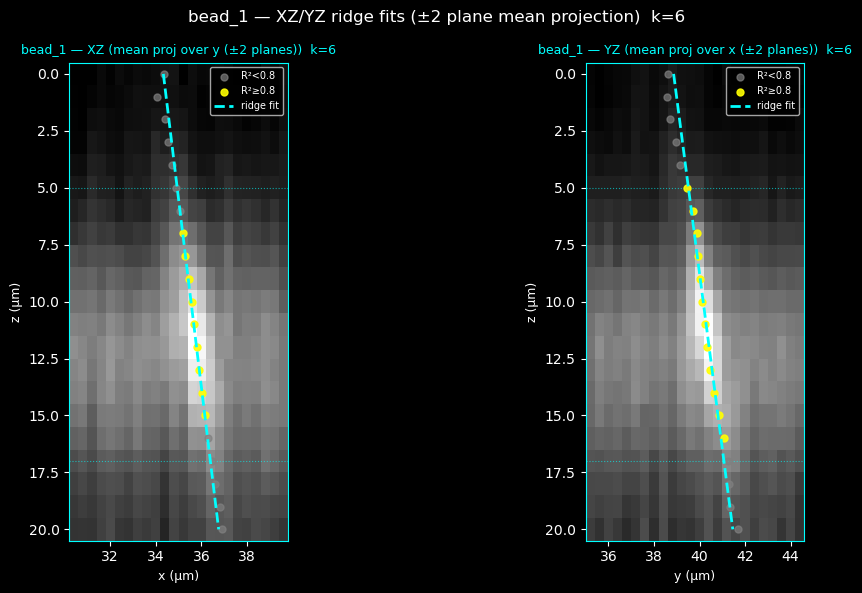

bead_2: brightest z plane = 13 (13.0 µm), projecting over z=11–15
bead_2: R² values in fit range:
    z=5 (5.0 µm): x R²=0.856, y R²=0.681
    z=6 (6.0 µm): x R²=0.699, y R²=0.737
    z=7 (7.0 µm): x R²=0.829, y R²=0.821
    z=8 (8.0 µm): x R²=0.900, y R²=0.902
    z=9 (9.0 µm): x R²=0.928, y R²=0.933
    z=10 (10.0 µm): x R²=0.937, y R²=0.958
    z=11 (11.0 µm): x R²=0.937, y R²=0.970
    z=12 (12.0 µm): x R²=0.943, y R²=0.958
    z=13 (13.0 µm): x R²=0.925, y R²=0.972
    z=14 (14.0 µm): x R²=0.917, y R²=0.931
    z=15 (15.0 µm): x R²=0.908, y R²=0.907
    z=16 (16.0 µm): x R²=0.906, y R²=0.863
    z=17 (17.0 µm): x R²=0.834, y R²=0.858
  XZ fit uses 12 planes, YZ fit uses 11 planes  (of 13 in range)
  XZ fit  x(z) = +0.0821*z + +41.163  µm
  YZ fit  y(z) = +0.1361*z + +62.609  µm


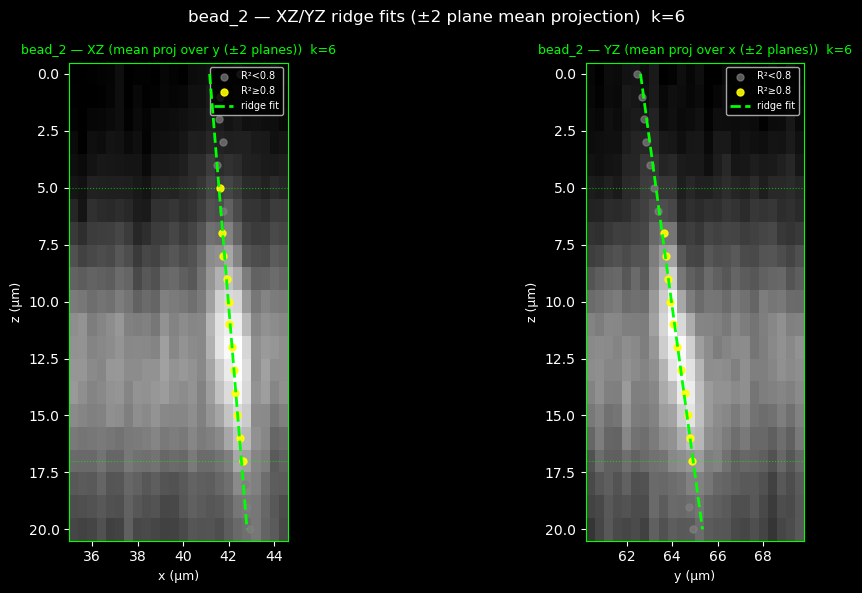

bead_3: brightest z plane = 9 (9.0 µm), projecting over z=7–11
bead_3: R² values in fit range:
    z=5 (5.0 µm): x R²=0.893, y R²=0.887
    z=6 (6.0 µm): x R²=0.941, y R²=0.913
    z=7 (7.0 µm): x R²=0.926, y R²=0.893
    z=8 (8.0 µm): x R²=0.885, y R²=0.903
    z=9 (9.0 µm): x R²=0.868, y R²=0.922
    z=10 (10.0 µm): x R²=0.822, y R²=0.904
    z=11 (11.0 µm): x R²=0.770, y R²=0.895
    z=12 (12.0 µm): x R²=0.807, y R²=0.863
    z=13 (13.0 µm): x R²=0.816, y R²=0.794
    z=14 (14.0 µm): x R²=0.765, y R²=0.756
    z=15 (15.0 µm): x R²=0.807, y R²=0.702
    z=16 (16.0 µm): x R²=0.798, y R²=0.677
    z=17 (17.0 µm): x R²=0.761, y R²=0.531
  XZ fit uses 9 planes, YZ fit uses 8 planes  (of 13 in range)
  XZ fit  x(z) = -0.0120*z + +67.584  µm
  YZ fit  y(z) = +0.1494*z + +87.297  µm


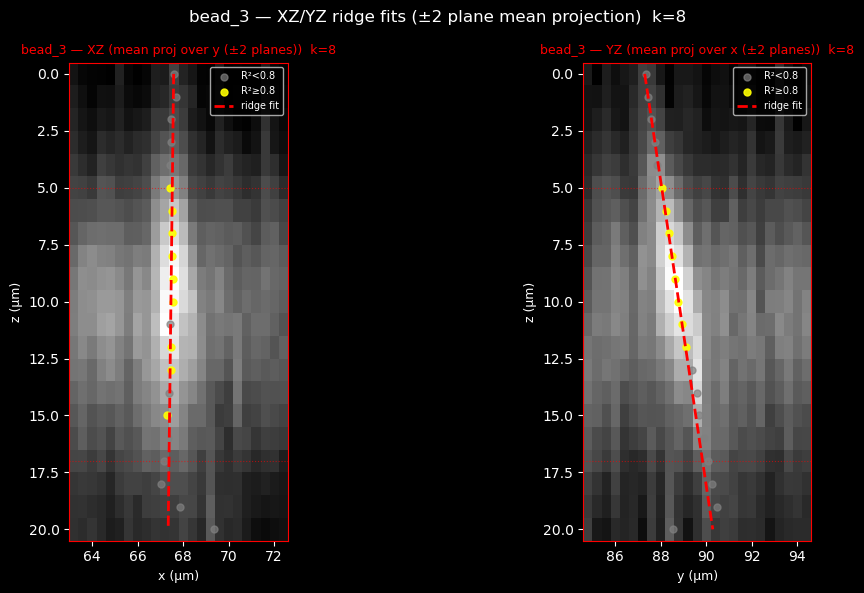


Done — beads dict updated with ridge-fitted xs_px, ys_px, com_bottom, com_top, line.
Run the lineout script next to sample and fit the axial PSF.


In [19]:
# the following script looks within each bead roi at it's respective time point, and fits a 2d line to XZ and YZ projections (near the PSF in XY)
# it then uses the 2d line projections to construct the 3d trajectory for a sampling line along the optical axis.

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# ══════════════════════════════════════════════════════════════════════════════
# EDIT THESE
# ══════════════════════════════════════════════════════════════════════════════
xy_spacing    = 0.4
z_spacing     = 1.0
r2_threshold  = 0.8   # minimum R² for Gaussian ridge fit to be included
# ══════════════════════════════════════════════════════════════════════════════

colors = ['cyan', 'lime', 'red', 'yellow', 'magenta']

def gaussian1d(x, amp, mu, sigma, offset):
    return amp * np.exp(-((x - mu)**2) / (2 * sigma**2)) + offset

def fit_row_gaussian(profile, x_um):
    try:
        bg   = np.percentile(profile, 10)
        amp0 = profile.max() - bg
        mu0  = x_um[np.argmax(profile)]
        p0   = [amp0, mu0, 0.5, bg]
        bounds = ([-np.inf, x_um[0],  0.05, -np.inf],
                  [ np.inf, x_um[-1], 5.0,   np.inf])
        popt, _ = curve_fit(gaussian1d, x_um, profile,
                            p0=p0, bounds=bounds, maxfev=2000)
        residuals = profile - gaussian1d(x_um, *popt)
        ss_res = np.sum(residuals**2)
        ss_tot = np.sum((profile - profile.mean())**2)
        r2 = 1 - ss_res / ss_tot if ss_tot > 0 else 0
        return popt[1], popt[2], r2   # mu, sigma, R²
    except Exception:
        return np.nan, np.nan, 0.0


# ══════════════════════════════════════════════════════════════════════════════
for (name, bead), color in zip(beads.items(), colors):
    k        = bead['k']
    z_bottom = bead['z_bottom']
    z_top    = bead['z_top']
    x0, x1, y0, y1 = bead['roi']

    nz, ny, nx = stack[k].shape
    z_orig_um  = np.arange(nz) * z_spacing
    z_bot_um   = z_bottom * z_spacing
    z_top_um   = z_top    * z_spacing

    # Physical axes for the ROI
    x_roi_um = np.arange(x0, x1) * xy_spacing   # absolute x in µm
    y_roi_um = np.arange(y0, y1) * xy_spacing   # absolute y in µm

    # ── Step 1: find brightest z plane in ROI, project ±n_planes around it ──────
    n_planes  = 2   # number of planes either side of peak to include in projection
    nx_roi = x1 - x0
    ny_roi = y1 - y0

    # Find brightest z plane within fit range using mean ROI intensity
    roi_full = stack[k, z_bottom:z_top+1, y0:y1, x0:x1].astype(float)
    z_mean_intensity = roi_full.mean(axis=(1, 2))
    best_zi_rel = int(np.argmax(z_mean_intensity))
    best_zi_abs = z_bottom + best_zi_rel
    bead['best_zi_abs'] = best_zi_abs   
    z_lo = max(0,  best_zi_abs - n_planes)
    z_hi = min(nz, best_zi_abs + n_planes + 1)
    print(f"{name}: brightest z plane = {best_zi_abs} ({best_zi_abs*z_spacing:.1f} µm), "
          f"projecting over z={z_lo}–{z_hi-1}")

    # For each z plane, project the ±n_planes neighbourhood
    xz_proj = np.zeros((nz, nx_roi), dtype=float)
    yz_proj = np.zeros((nz, ny_roi), dtype=float)

    for zi in range(nz):
        z_lo_i = max(0,  zi - n_planes)
        z_hi_i = min(nz, zi + n_planes + 1)
        neighbourhood = stack[k, z_lo_i:z_hi_i, y0:y1, x0:x1].astype(float)
        xz_proj[zi] = neighbourhood.mean(axis=(0, 1))   # collapse z and y → (nx_roi,)
        yz_proj[zi] = neighbourhood.mean(axis=(0, 2))   # collapse z and x → (ny_roi,)

    # ── Step 2: Gaussian fit to each z-plane row ──────────────────────────────
    x_ridge_um = np.full(nz, np.nan)
    y_ridge_um = np.full(nz, np.nan)
    x_sigma_um = np.full(nz, np.nan)
    y_sigma_um = np.full(nz, np.nan)
    x_r2       = np.zeros(nz)
    y_r2       = np.zeros(nz)

    for zi in range(nz):
        x_ridge_um[zi], x_sigma_um[zi], x_r2[zi] = fit_row_gaussian(
            xz_proj[zi], x_roi_um)
        y_ridge_um[zi], y_sigma_um[zi], y_r2[zi] = fit_row_gaussian(
            yz_proj[zi], y_roi_um)

    # ── Step 3: linear fit within z_bottom–z_top, each dim independently ──────
    in_range = (z_orig_um >= z_bot_um) & (z_orig_um <= z_top_um)
    x_mask = in_range & (x_r2 >= r2_threshold) & np.isfinite(x_ridge_um)
    y_mask = in_range & (y_r2 >= r2_threshold) & np.isfinite(y_ridge_um)

    # Print R² values for all in-range planes to help tune threshold
    print(f"{name}: R² values in fit range:")
    for zi in np.where(in_range)[0]:
        print(f"    z={zi} ({z_orig_um[zi]:.1f} µm): "
              f"x R²={x_r2[zi]:.3f}, y R²={y_r2[zi]:.3f}")

    print(f"  XZ fit uses {x_mask.sum()} planes, "
          f"YZ fit uses {y_mask.sum()} planes  (of {int(z_top-z_bottom+1)} in range)")

    # Fallback: if no planes pass threshold, use all in-range finite planes
    if x_mask.sum() < 2:
        print(f"  WARNING: too few XZ planes pass R²>{r2_threshold}, "
              f"using all in-range finite planes")
        x_mask = in_range & np.isfinite(x_ridge_um)
    if y_mask.sum() < 2:
        print(f"  WARNING: too few YZ planes pass R²>{r2_threshold}, "
              f"using all in-range finite planes")
        y_mask = in_range & np.isfinite(y_ridge_um)

    px_x = np.polyfit(z_orig_um[x_mask], x_ridge_um[x_mask], 1)
    px_y = np.polyfit(z_orig_um[y_mask], y_ridge_um[y_mask], 1)

    # Ridge positions are already in absolute µm — convert to pixels
    new_xs_px = np.polyval(px_x, z_orig_um) / xy_spacing
    new_ys_px = np.polyval(px_y, z_orig_um) / xy_spacing

    # Clamp outside fit range
    new_xs_px = np.where(z_orig_um < z_bot_um,
                         np.polyval(px_x, z_bot_um) / xy_spacing,
                np.where(z_orig_um > z_top_um,
                         np.polyval(px_x, z_top_um) / xy_spacing,
                         new_xs_px))
    new_ys_px = np.where(z_orig_um < z_bot_um,
                         np.polyval(px_y, z_bot_um) / xy_spacing,
                np.where(z_orig_um > z_top_um,
                         np.polyval(px_y, z_top_um) / xy_spacing,
                         new_ys_px))

    bead['xs_px'] = new_xs_px
    bead['ys_px'] = new_ys_px

    # 3D line endpoints
    cx_bot = np.polyval(px_x, z_bot_um) / xy_spacing
    cy_bot = np.polyval(px_y, z_bot_um) / xy_spacing
    cx_top = np.polyval(px_x, z_top_um) / xy_spacing
    cy_top = np.polyval(px_y, z_top_um) / xy_spacing

    bead['com_bottom'] = (cx_bot, cy_bot)
    bead['com_top']    = (cx_top, cy_top)
    bead['line'] = (cx_bot * xy_spacing, cy_bot * xy_spacing, z_bot_um,
                    cx_top * xy_spacing, cy_top * xy_spacing, z_top_um)

    print(f"  XZ fit  x(z) = {px_x[0]:+.4f}*z + {px_x[1]:+.3f}  µm")
    print(f"  YZ fit  y(z) = {px_y[0]:+.4f}*z + {px_y[1]:+.3f}  µm")

    # ── Diagnostic plot: XZ and YZ ridge fits only ───────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(12, 6), facecolor='black')

    for ax, img, ridge_um, r2_vals, good_mask, px_fit, roi_um, dim_label in [
        (axes[0], xz_proj, x_ridge_um, x_r2, x_mask, px_x, x_roi_um, 'x'),
        (axes[1], yz_proj, y_ridge_um, y_r2, y_mask, px_y, y_roi_um, 'y'),
    ]:
        rv_min = np.percentile(img, 1)
        rv_max = np.percentile(img, 99.9)
        ax.pcolormesh(roi_um, z_orig_um, img,
                      cmap='gray', vmin=rv_min, vmax=rv_max)
        ax.set_aspect('equal')
        ax.invert_yaxis()

        bad = (~good_mask) & np.isfinite(ridge_um)
        ax.scatter(ridge_um[bad],       z_orig_um[bad],
                   c='gray',   s=25, alpha=0.7, label=f'R²<{r2_threshold}', zorder=4)
        ax.scatter(ridge_um[good_mask], z_orig_um[good_mask],
                   c='yellow', s=25, alpha=0.9, label=f'R²≥{r2_threshold}', zorder=5)

        z_line = np.linspace(z_orig_um[0], z_orig_um[-1], 100)
        ax.plot(np.polyval(px_fit, z_line), z_line,
                color=color, lw=2, ls='--', label='ridge fit', zorder=6)
        ax.axhline(z_bot_um, color=color, lw=0.8, ls=':', alpha=0.6)
        ax.axhline(z_top_um, color=color, lw=0.8, ls=':', alpha=0.6)
        ax.set_facecolor('black')
        ax.tick_params(colors='white')
        ax.set_xlabel(f'{dim_label} (µm)', color='white', fontsize=9)
        ax.set_ylabel('z (µm)', color='white', fontsize=9)
        proj_label = 'mean proj over y (±2 planes)' if dim_label == 'x' else 'mean proj over x (±2 planes)'
        ax.set_title(f'{name} — {dim_label.upper()}Z ({proj_label})  k={k}',
                     color=color, fontsize=9)
        ax.legend(fontsize=7, facecolor='black', labelcolor='white', loc='upper right')
        for sp in ax.spines.values(): sp.set_edgecolor(color)

    fig.suptitle(f'{name} — XZ/YZ ridge fits (±2 plane mean projection)  k={k}',
                 color='white', fontsize=12)
    plt.tight_layout()
    # plt.savefig(rf"Z:/Dropbox/Aaron/bead_visualization_5frame_newzach/1um/100fr/bead_ridge_fit_{name}.png",
                # dpi=200, bbox_inches='tight', facecolor='black')
    plt.show()

print("\nDone — beads dict updated with ridge-fitted xs_px, ys_px, com_bottom, com_top, line.")
print("Run the lineout script next to sample and fit the axial PSF.")

C:\Users\farin012\AppData\Local\Temp\ipykernel_32188\2520244023.py:83: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, _ = curve_fit(gaussian_z, t_um, profile, p0=p0, maxfev=5000)


bead_1: σ = 3381 nm, FWHM = 7962 nm
  Peak at z=12 (11.6 µm): x=35.79 µm, y=40.42 µm


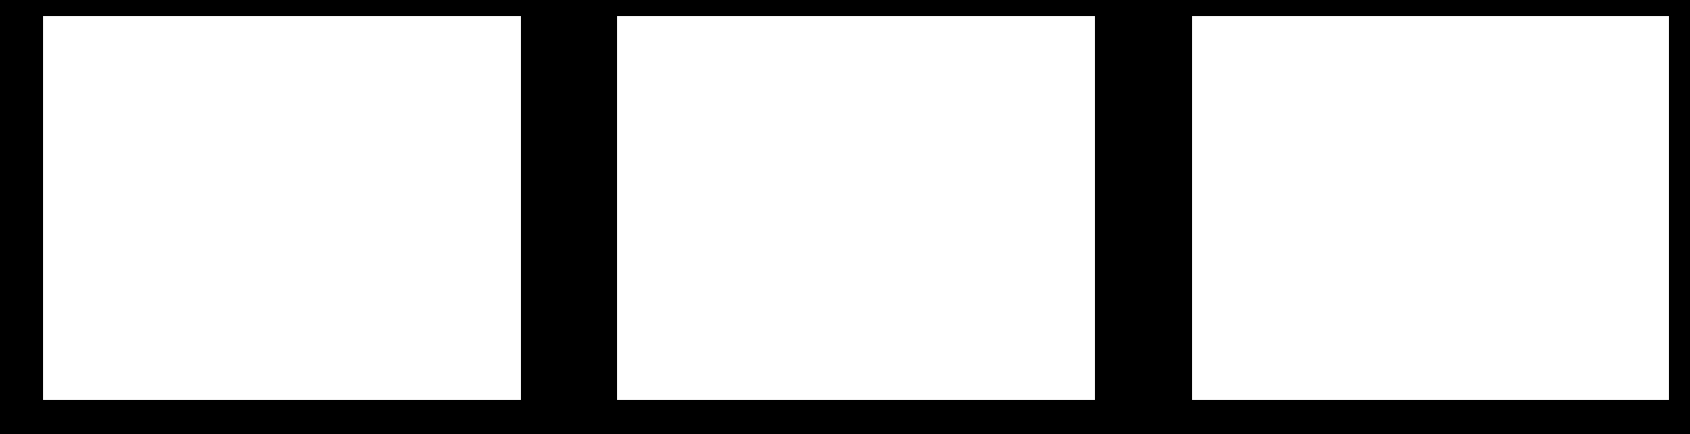

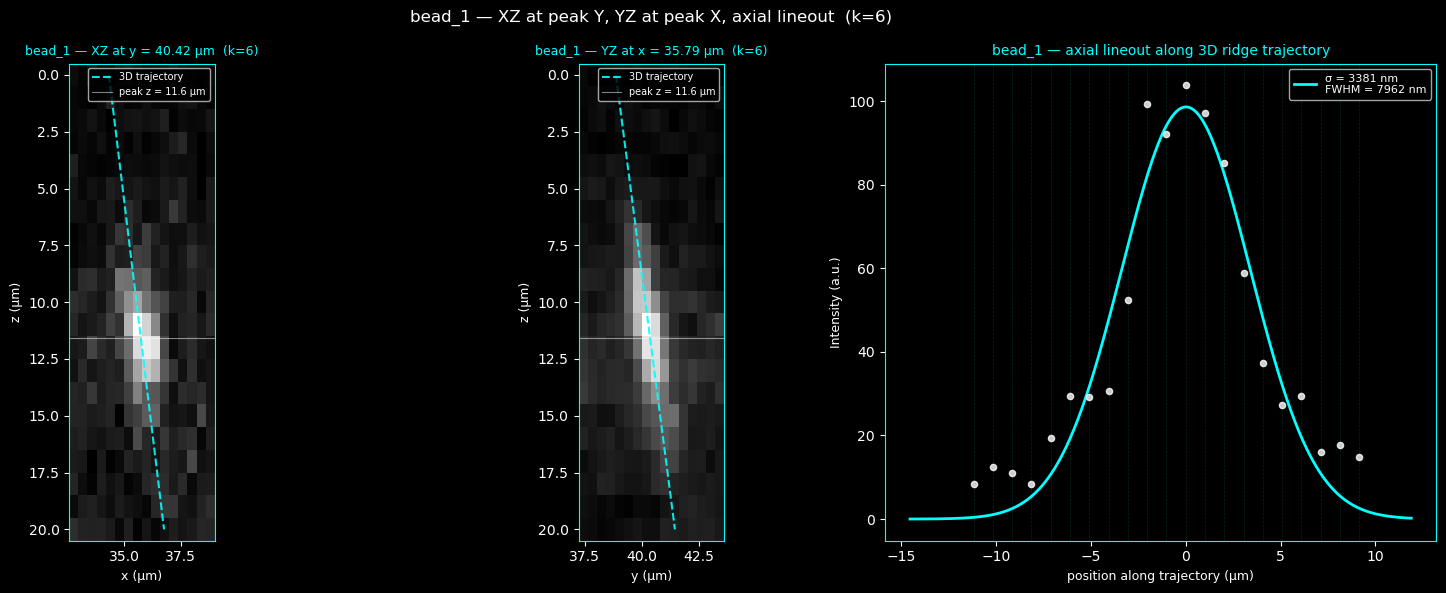

bead_2: σ = 4247 nm, FWHM = 10002 nm
  Peak at z=12 (12.2 µm): x=42.15 µm, y=64.24 µm


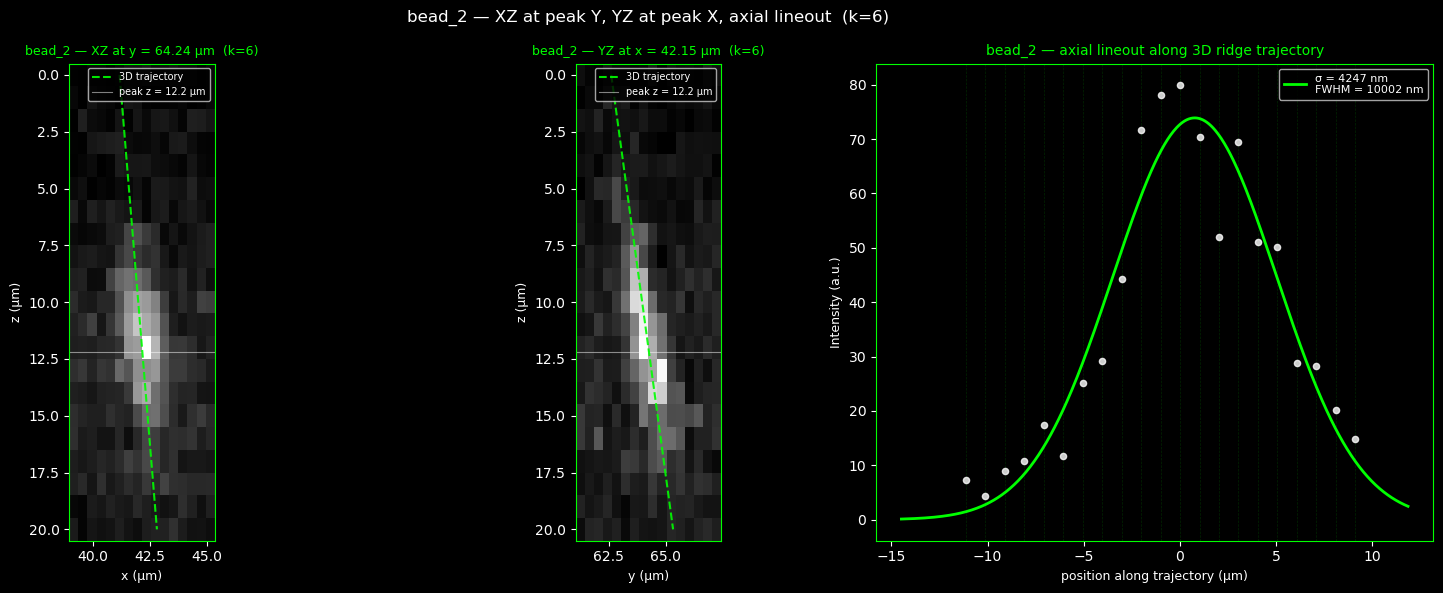

bead_3: σ = 5914 nm, FWHM = 13927 nm
  Peak at z=10 (9.8 µm): x=67.46 µm, y=88.79 µm


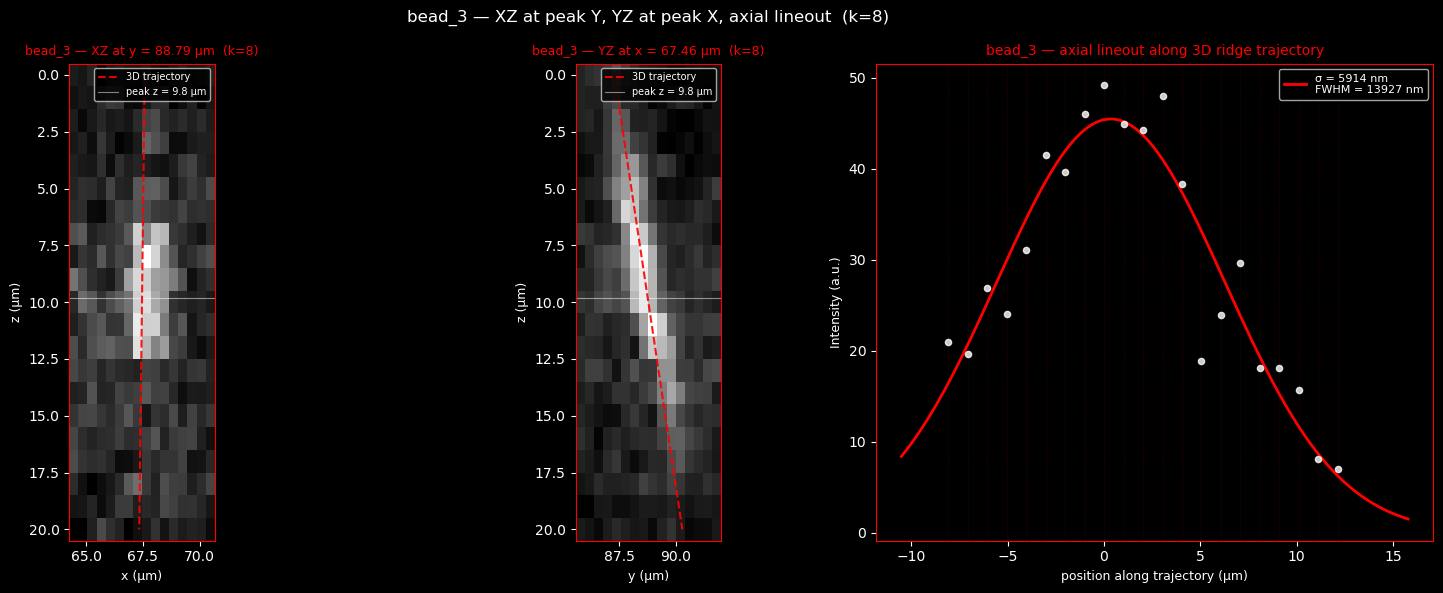

<Figure size 640x480 with 0 Axes>


── Summary ──
bead_1 (k=6, z=5–17): σ = 3381 nm, FWHM = 7962 nm
bead_2 (k=6, z=5–17): σ = 4247 nm, FWHM = 10002 nm
bead_3 (k=8, z=5–17): σ = 5914 nm, FWHM = 13927 nm


In [20]:
# this code uses the X,Y coordinate of the peak of the 3D axial fit to define a 'slice' through the center of each PSF
# eg., XZ slices through this "Y" coordinate, and YZ slices through this "X" coordinate.
# additionally, the projection of the trajectory of the axial fit can be visualizes in XZ and YZ
# finally, the third panels shows the intensity values along the axial lineout fit through 3d space and along the optical axis

import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import map_coordinates
from scipy.optimize import curve_fit

# ══════════════════════════════════════════════════════════════════════════════
# EDIT THESE
# ══════════════════════════════════════════════════════════════════════════════
xy_spacing    = 0.4
z_spacing     = 1.0
half_width_um = 3.0   # µm either side of peak X/Y to show in cross-sections
# ══════════════════════════════════════════════════════════════════════════════

colors = ['cyan', 'lime', 'red', 'yellow', 'magenta']

def gaussian_z(x, amp, mu, sigma, offset):
    return amp * np.exp(-((x - mu)**2) / (2 * sigma**2)) 

def sample_line_3d(stack_k, x1_um, y1_um, z1_um, x2_um, y2_um, z2_um,
                   x_spacing, z_spacing_):
    x1 = x1_um / x_spacing;  x2 = x2_um / x_spacing
    y1 = y1_um / x_spacing;  y2 = y2_um / x_spacing
    z1 = z1_um / z_spacing_; z2 = z2_um / z_spacing_

    dx = x2 - x1; dy = y2 - y1; dz = z2 - z1
    length = np.sqrt(dx**2 + dy**2 + dz**2)
    dx /= length; dy /= length; dz /= length

    nz_, ny_, nx_ = stack_k.shape
    cx = (x1 + x2) / 2; cy = (y1 + y2) / 2; cz = (z1 + z2) / 2
    z_indices = np.arange(nz_).astype(float)
    t_vals = (z_indices - cz) / dz if abs(dz) > 1e-6 else z_indices - nz_ / 2

    xs = cx + t_vals * dx
    ys = cy + t_vals * dy
    zs = cz + t_vals * dz

    mask = (xs >= 0) & (xs < nx_-1) & (ys >= 0) & (ys < ny_-1)
    profile = map_coordinates(stack_k.astype(float),
                              [zs[mask], ys[mask], xs[mask]], order=1)
    t_um = t_vals[mask] * np.sqrt((dx * x_spacing)**2 +
                                   (dy * x_spacing)**2 +
                                   (dz * z_spacing_)**2)
    t_um = t_um - t_um[np.argmax(profile)]
    return t_um, profile

# ══════════════════════════════════════════════════════════════════════════════
n_beads = len(beads)
fig_summary, axes_summary = plt.subplots(1, n_beads,
                                          figsize=(7 * n_beads, 5),
                                          facecolor='black')
if n_beads == 1:
    axes_summary = [axes_summary]

for ax_sum, (name, bead), color in zip(axes_summary, beads.items(), colors):
    k        = bead['k']
    z_bottom = bead['z_bottom']
    z_top    = bead['z_top']
    xs_px    = bead['xs_px']
    ys_px    = bead['ys_px']

    nz, ny, nx = stack[k].shape
    z_orig_um = np.arange(nz) * z_spacing
    z_bot_um  = z_bottom * z_spacing
    z_top_um  = z_top    * z_spacing

    # ── Step 1: sample 3D lineout and fit Gaussian ────────────────────────────
    x1_um, y1_um, z1_um, x2_um, y2_um, z2_um = bead['line']
    t_um, profile = sample_line_3d(
        stack[k], x1_um, y1_um, z1_um, x2_um, y2_um, z2_um,
        xy_spacing, z_spacing)

    bead['t_um']    = t_um
    bead['profile'] = profile

    try:
        p0 = [profile.max()-profile.min(), t_um[np.argmax(profile)], 2.0, profile.min()]
        popt, _ = curve_fit(gaussian_z, t_um, profile, p0=p0, maxfev=5000)
        bead['fwhm_nm']  = abs(popt[2]) * 2.355 * 1000
        bead['sigma_nm'] = abs(popt[2]) * 1000
        bead['popt']     = popt
        print(f"{name}: σ = {bead['sigma_nm']:.0f} nm, FWHM = {bead['fwhm_nm']:.0f} nm")
    except Exception as e:
        print(f"{name} Gaussian fit failed: {e}")
        bead['popt'] = None

    # ── Step 2: find X, Y at the Gaussian peak ────────────────────────────────
    line_z_um = np.linspace(z_bot_um, z_top_um, len(t_um))
    if bead['popt'] is not None:
        peak_idx = int(np.argmin(np.abs(t_um - popt[1])))
    else:
        peak_idx = int(np.argmax(profile))

    peak_z_um = line_z_um[peak_idx]
    peak_zi   = int(np.clip(np.round(peak_z_um / z_spacing), 0, nz-1))
    peak_x_um = xs_px[peak_zi] * xy_spacing
    peak_y_um = ys_px[peak_zi] * xy_spacing

    print(f"  Peak at z={peak_zi} ({peak_z_um:.1f} µm): "
          f"x={peak_x_um:.2f} µm, y={peak_y_um:.2f} µm")

    # ── Step 3: XZ slice at peak_y, YZ slice at peak_x ───────────────────────
    hw_px     = half_width_um / xy_spacing
    n_samp    = int(2 * hw_px) + 1
    peak_x_px = peak_x_um / xy_spacing
    peak_y_px = peak_y_um / xy_spacing

    x_samp_px = np.linspace(peak_x_px - hw_px, peak_x_px + hw_px, n_samp)
    x_samp_um = x_samp_px * xy_spacing
    y_samp_px = np.linspace(peak_y_px - hw_px, peak_y_px + hw_px, n_samp)
    y_samp_um = y_samp_px * xy_spacing

    xz_img = np.zeros((nz, n_samp), dtype=float)
    yz_img = np.zeros((nz, n_samp), dtype=float)

    for zi in range(nz):
        for i, xc in enumerate(x_samp_px):
            yc = peak_y_px
            if 0 <= xc < nx-1 and 0 <= yc < ny-1:
                xz_img[zi, i] = map_coordinates(
                    stack[k].astype(float), [[zi], [yc], [xc]], order=1)[0]
        for i, yc in enumerate(y_samp_px):
            xc = peak_x_px
            if 0 <= xc < nx-1 and 0 <= yc < ny-1:
                yz_img[zi, i] = map_coordinates(
                    stack[k].astype(float), [[zi], [yc], [xc]], order=1)[0]

    # ── Step 4: trajectory line — extrapolate slope across full z range ───────
    # Slope from the two fitted endpoints (z_bot → z_top)
    dz_fit  = z_top_um - z_bot_um
    slope_x = (x2_um - x1_um) / dz_fit   # µm per µm
    slope_y = (y2_um - y1_um) / dz_fit

    z_full      = z_orig_um   # all 21 z planes
    traj_x_full = x1_um + slope_x * (z_full - z_bot_um)
    traj_y_full = y1_um + slope_y * (z_full - z_bot_um)

    # ── Step 5: plot ──────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(16, 6), facecolor='black')

    for ax, img, samp_um, dim_label, traj_um, slice_label in [
        (axes[0], xz_img, x_samp_um, 'x', traj_x_full,
         f'y = {peak_y_um:.2f} µm'),
        (axes[1], yz_img, y_samp_um, 'y', traj_y_full,
         f'x = {peak_x_um:.2f} µm'),
    ]:
        rv_min = np.percentile(img, 1)
        rv_max = np.percentile(img, 99.9)
        ax.pcolormesh(samp_um, z_orig_um, img,
                      cmap='gray', vmin=rv_min, vmax=rv_max)
        ax.set_aspect('equal')
        ax.invert_yaxis()

        # The actual 3D trajectory — straight line extrapolated across full z
        ax.plot(traj_um, z_full, color=color, lw=1.5, ls='--', alpha=0.9,
                label='3D trajectory', zorder=5)
        ax.axhline(peak_z_um, color='white', lw=0.8, ls='-', alpha=0.5,
                   label=f'peak z = {peak_z_um:.1f} µm')

        ax.set_facecolor('black')
        ax.tick_params(colors='white')
        ax.set_xlabel(f'{dim_label} (µm)', color='white', fontsize=9)
        ax.set_ylabel('z (µm)', color='white', fontsize=9)
        ax.set_title(f'{name} — {dim_label.upper()}Z at {slice_label}  (k={k})',
                     color=color, fontsize=9)
        ax.legend(fontsize=7, facecolor='black', labelcolor='white', loc='upper right')
        for sp in ax.spines.values(): sp.set_edgecolor(color)

    # Axial lineout
    ax3 = axes[2]
    for t in t_um:
        ax3.axvline(t, color=color, lw=0.5, alpha=0.15, ls='--')
    ax3.scatter(t_um, profile, color='white', s=20, alpha=0.8, zorder=3)
    if bead['popt'] is not None:
        popt = bead['popt']
        t_fit = np.linspace(t_um.min() * 1.3, t_um.max() * 1.3, 500)
        ax3.plot(t_fit, gaussian_z(t_fit, *popt), color=color, lw=2,
                 label=f'σ = {bead["sigma_nm"]:.0f} nm\n'
                       f'FWHM = {bead["fwhm_nm"]:.0f} nm')
        ax3.legend(fontsize=8, facecolor='black', labelcolor='white')
    ax3.set_facecolor('black')
    ax3.tick_params(colors='white')
    ax3.set_xlabel('position along trajectory (µm)', color='white', fontsize=9)
    ax3.set_ylabel('Intensity (a.u.)', color='white', fontsize=9)
    ax3.set_title(f'{name} — axial lineout along 3D ridge trajectory',
                  color=color, fontsize=10)
    for sp in ax3.spines.values(): sp.set_edgecolor(color)

    fig.suptitle(f'{name} — XZ at peak Y, YZ at peak X, axial lineout  (k={k})',
                 color='white', fontsize=12)
    plt.tight_layout()
    # plt.savefig(rf"Z:/Dropbox/Aaron/bead_visualization_5frame_newzach/1um/100fr/bead_lineout_{name}.png",
    #             dpi=200, bbox_inches='tight', facecolor='black')
    plt.show()

    # Summary
    for t in t_um:
        ax_sum.axvline(t, color=color, lw=0.5, alpha=0.15, ls='--')
    ax_sum.scatter(t_um, profile, color='white', s=20, alpha=0.8, zorder=3)
    if bead['popt'] is not None:
        popt = bead['popt']
        t_fit = np.linspace(t_um.min() * 1.3, t_um.max() * 1.3, 500)
        ax_sum.plot(t_fit, gaussian_z(t_fit, *popt), color=color, lw=2,
                    label=f'{name}\nσ={bead["sigma_nm"]:.0f} nm\n'
                          f'FWHM={bead["fwhm_nm"]:.0f} nm')
        ax_sum.legend(fontsize=7, facecolor='black', labelcolor='white')
    ax_sum.set_facecolor('black')
    ax_sum.tick_params(colors='white')
    ax_sum.set_xlabel('position along trajectory (µm)', color='white', fontsize=9)
    ax_sum.set_ylabel('Intensity (a.u.)', color='white', fontsize=9)
    ax_sum.set_title(f'{name}', color=color, fontsize=10)
    for sp in ax_sum.spines.values(): sp.set_edgecolor(color)

fig_summary.suptitle('Axial PSF lineouts along 3D ridge trajectories',
                     color='white', fontsize=12)
plt.tight_layout()
# fig_summary.savefig(r"Z:/Dropbox/Aaron/bead_visualization_5frame_newzach/1um/100fr/bead_lineouts_summary.png",
#                     dpi=200, bbox_inches='tight', facecolor='black')
plt.show()

print("\n── Summary ──")
for name, bead in beads.items():
    if 'fwhm_nm' in bead:
        print(f"{name} (k={bead['k']}, z={bead['z_bottom']}–{bead['z_top']}): "
              f"σ = {bead['sigma_nm']:.0f} nm, FWHM = {bead['fwhm_nm']:.0f} nm")


C:\Users\farin012\AppData\Local\Temp\ipykernel_32188\3926657479.py:81: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, _ = curve_fit(gaussian_z, t_um, profile, p0=p0, maxfev=5000)


bead_1: σ = 3381 nm, FWHM = 7962 nm
  Peak at z=12 (11.6 µm): x=35.79 µm, y=40.42 µm


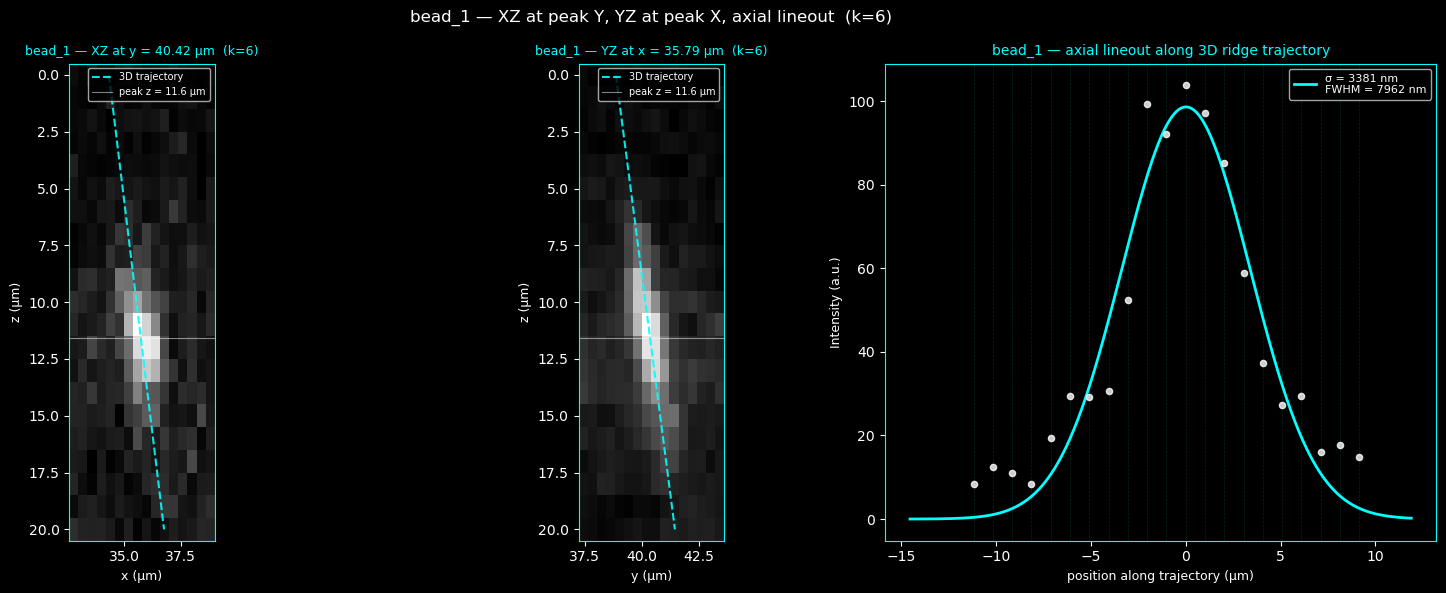

bead_2: σ = 4247 nm, FWHM = 10002 nm
  Peak at z=12 (12.2 µm): x=42.15 µm, y=64.24 µm


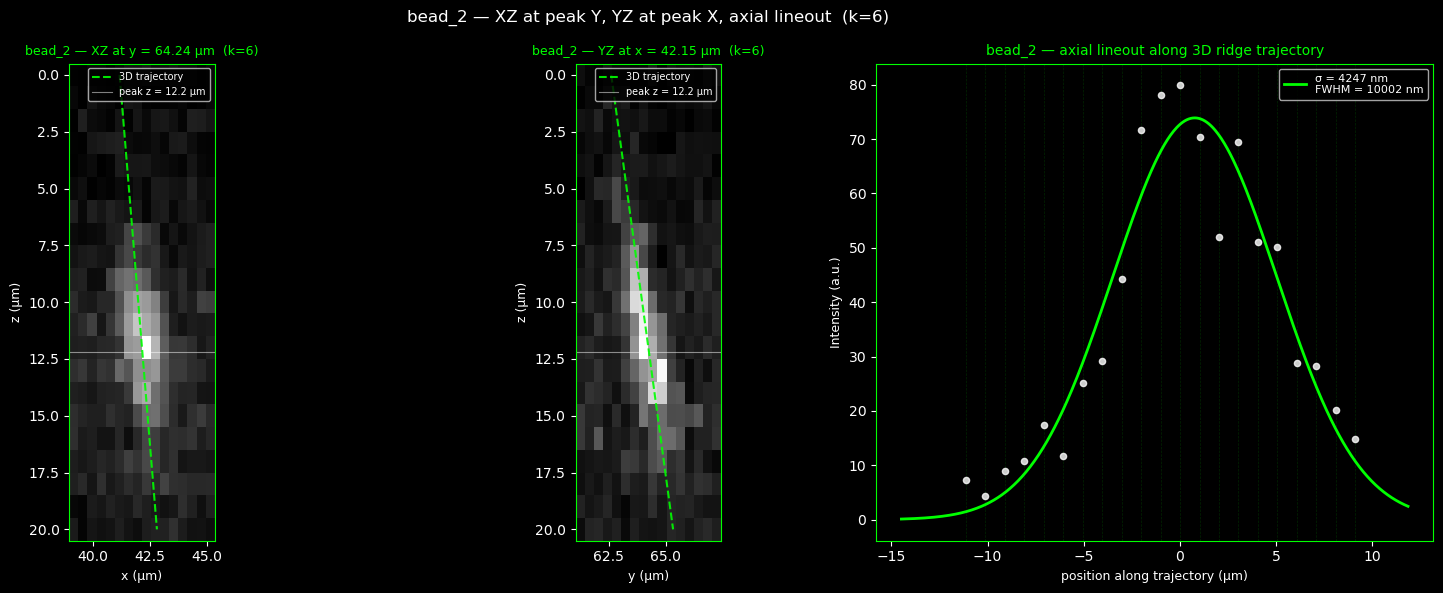

bead_3: σ = 5914 nm, FWHM = 13927 nm
  Peak at z=10 (9.8 µm): x=67.46 µm, y=88.79 µm


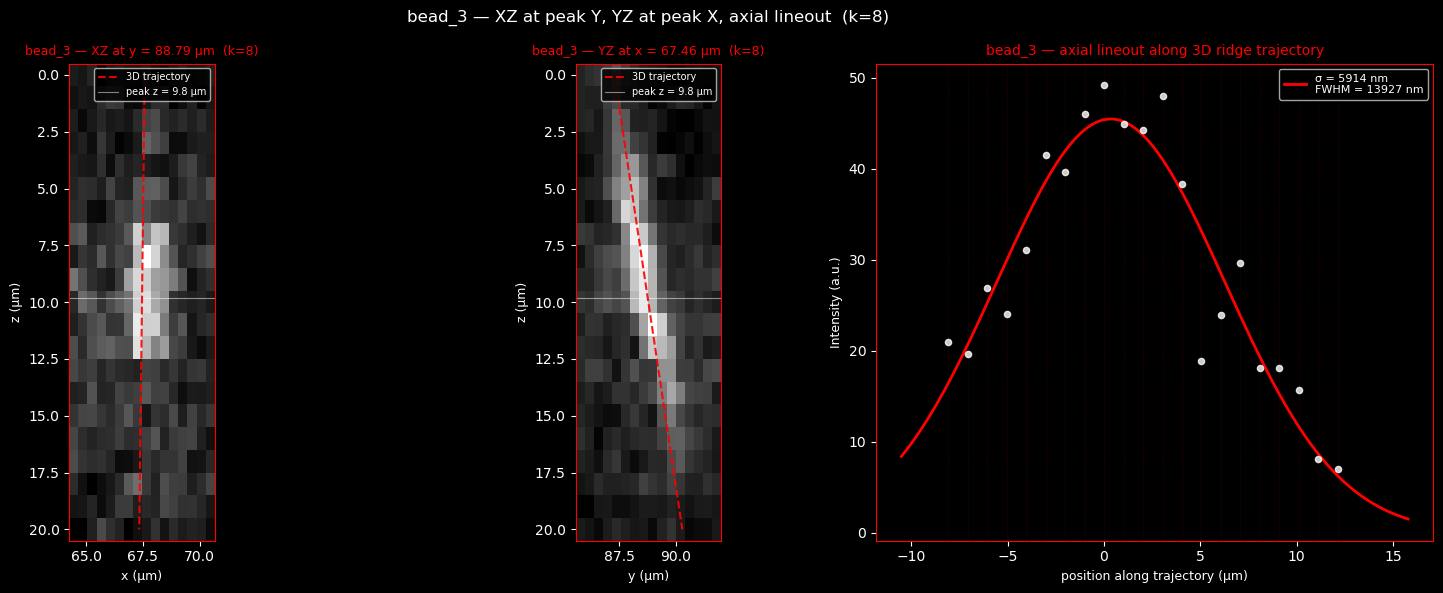

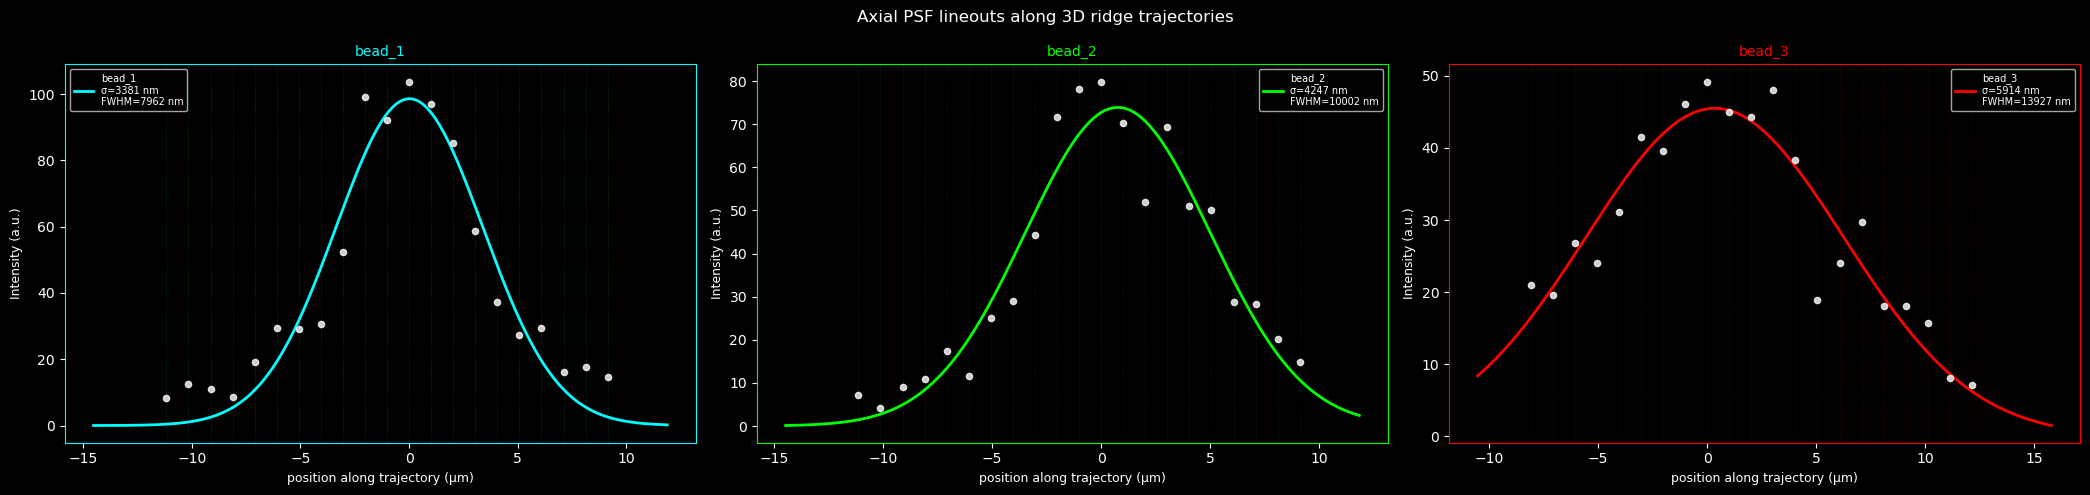


── Summary ──
bead_1 (k=6, z=5–17): σ = 3381 nm, FWHM = 7962 nm
bead_2 (k=6, z=5–17): σ = 4247 nm, FWHM = 10002 nm
bead_3 (k=8, z=5–17): σ = 5914 nm, FWHM = 13927 nm


In [21]:
# this code uses the X,Y coordinate of the peak of the 3D axial fit to define a 'slice' through the center of each PSF
# eg., XZ slices through this "Y" coordinate, and YZ slices through this "X" coordinate.
# additionally, the projection of the trajectory of the axial fit can be visualizes in XZ and YZ
# finally, the third panels shows the intensity values along the axial lineout fit through 3d space and along the optical axis

import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import map_coordinates
from scipy.optimize import curve_fit

# ══════════════════════════════════════════════════════════════════════════════
# EDIT THESE
# ══════════════════════════════════════════════════════════════════════════════
xy_spacing    = 0.4
z_spacing     = 1.0
half_width_um = 3.0   # µm either side of peak X/Y to show in cross-sections
# ══════════════════════════════════════════════════════════════════════════════

colors = ['cyan', 'lime', 'red', 'yellow', 'magenta']

def gaussian_z(x, amp, mu, sigma, offset):
    return amp * np.exp(-((x - mu)**2) / (2 * sigma**2)) 

def sample_line_3d(stack_k, x1_um, y1_um, z1_um, x2_um, y2_um, z2_um,
                   x_spacing, z_spacing_):
    x1 = x1_um / x_spacing;  x2 = x2_um / x_spacing
    y1 = y1_um / x_spacing;  y2 = y2_um / x_spacing
    z1 = z1_um / z_spacing_; z2 = z2_um / z_spacing_

    dx = x2 - x1; dy = y2 - y1; dz = z2 - z1
    length = np.sqrt(dx**2 + dy**2 + dz**2)
    dx /= length; dy /= length; dz /= length

    nz_, ny_, nx_ = stack_k.shape
    cx = (x1 + x2) / 2; cy = (y1 + y2) / 2; cz = (z1 + z2) / 2
    z_indices = np.arange(nz_).astype(float)
    t_vals = (z_indices - cz) / dz if abs(dz) > 1e-6 else z_indices - nz_ / 2

    xs = cx + t_vals * dx
    ys = cy + t_vals * dy
    zs = cz + t_vals * dz

    mask = (xs >= 0) & (xs < nx_-1) & (ys >= 0) & (ys < ny_-1)
    profile = map_coordinates(stack_k.astype(float),
                              [zs[mask], ys[mask], xs[mask]], order=1)
    t_um = t_vals[mask] * np.sqrt((dx * x_spacing)**2 +
                                   (dy * x_spacing)**2 +
                                   (dz * z_spacing_)**2)
    t_um = t_um - t_um[np.argmax(profile)]
    return t_um, profile

# ══════════════════════════════════════════════════════════════════════════════
n_beads = len(beads)

# NOTE: fig_summary is created AFTER the loop to prevent it rendering empty
# when plt.show() is called inside the loop

for (name, bead), color in zip(beads.items(), colors):
    k        = bead['k']
    z_bottom = bead['z_bottom']
    z_top    = bead['z_top']
    xs_px    = bead['xs_px']
    ys_px    = bead['ys_px']

    nz, ny, nx = stack[k].shape
    z_orig_um = np.arange(nz) * z_spacing
    z_bot_um  = z_bottom * z_spacing
    z_top_um  = z_top    * z_spacing

    # ── Step 1: sample 3D lineout and fit Gaussian ────────────────────────────
    x1_um, y1_um, z1_um, x2_um, y2_um, z2_um = bead['line']
    t_um, profile = sample_line_3d(
        stack[k], x1_um, y1_um, z1_um, x2_um, y2_um, z2_um,
        xy_spacing, z_spacing)

    bead['t_um']    = t_um
    bead['profile'] = profile

    try:
        p0 = [profile.max()-profile.min(), t_um[np.argmax(profile)], 2.0, profile.min()]
        popt, _ = curve_fit(gaussian_z, t_um, profile, p0=p0, maxfev=5000)
        bead['fwhm_nm']  = abs(popt[2]) * 2.355 * 1000
        bead['sigma_nm'] = abs(popt[2]) * 1000
        bead['popt']     = popt
        print(f"{name}: σ = {bead['sigma_nm']:.0f} nm, FWHM = {bead['fwhm_nm']:.0f} nm")
    except Exception as e:
        print(f"{name} Gaussian fit failed: {e}")
        bead['popt'] = None

    # ── Step 2: find X, Y at the Gaussian peak ────────────────────────────────
    line_z_um = np.linspace(z_bot_um, z_top_um, len(t_um))
    if bead['popt'] is not None:
        peak_idx = int(np.argmin(np.abs(t_um - popt[1])))
    else:
        peak_idx = int(np.argmax(profile))

    peak_z_um = line_z_um[peak_idx]
    peak_zi   = int(np.clip(np.round(peak_z_um / z_spacing), 0, nz-1))
    peak_x_um = xs_px[peak_zi] * xy_spacing
    peak_y_um = ys_px[peak_zi] * xy_spacing

    print(f"  Peak at z={peak_zi} ({peak_z_um:.1f} µm): "
          f"x={peak_x_um:.2f} µm, y={peak_y_um:.2f} µm")

    # ── Step 3: XZ slice at peak_y, YZ slice at peak_x ───────────────────────
    hw_px     = half_width_um / xy_spacing
    n_samp    = int(2 * hw_px) + 1
    peak_x_px = peak_x_um / xy_spacing
    peak_y_px = peak_y_um / xy_spacing

    x_samp_px = np.linspace(peak_x_px - hw_px, peak_x_px + hw_px, n_samp)
    x_samp_um = x_samp_px * xy_spacing
    y_samp_px = np.linspace(peak_y_px - hw_px, peak_y_px + hw_px, n_samp)
    y_samp_um = y_samp_px * xy_spacing

    xz_img = np.zeros((nz, n_samp), dtype=float)
    yz_img = np.zeros((nz, n_samp), dtype=float)

    for zi in range(nz):
        for i, xc in enumerate(x_samp_px):
            yc = peak_y_px
            if 0 <= xc < nx-1 and 0 <= yc < ny-1:
                xz_img[zi, i] = map_coordinates(
                    stack[k].astype(float), [[zi], [yc], [xc]], order=1)[0]
        for i, yc in enumerate(y_samp_px):
            xc = peak_x_px
            if 0 <= xc < nx-1 and 0 <= yc < ny-1:
                yz_img[zi, i] = map_coordinates(
                    stack[k].astype(float), [[zi], [yc], [xc]], order=1)[0]

    # ── Step 4: trajectory line — extrapolate slope across full z range ───────
    # Slope from the two fitted endpoints (z_bot → z_top)
    dz_fit  = z_top_um - z_bot_um
    slope_x = (x2_um - x1_um) / dz_fit   # µm per µm
    slope_y = (y2_um - y1_um) / dz_fit

    z_full      = z_orig_um   # all 21 z planes
    traj_x_full = x1_um + slope_x * (z_full - z_bot_um)
    traj_y_full = y1_um + slope_y * (z_full - z_bot_um)

    # ── Step 5: plot ──────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(16, 6), facecolor='black')

    for ax, img, samp_um, dim_label, traj_um, slice_label in [
        (axes[0], xz_img, x_samp_um, 'x', traj_x_full,
         f'y = {peak_y_um:.2f} µm'),
        (axes[1], yz_img, y_samp_um, 'y', traj_y_full,
         f'x = {peak_x_um:.2f} µm'),
    ]:
        rv_min = np.percentile(img, 1)
        rv_max = np.percentile(img, 99.9)
        ax.pcolormesh(samp_um, z_orig_um, img,
                      cmap='gray', vmin=rv_min, vmax=rv_max)
        ax.set_aspect('equal')
        ax.invert_yaxis()

        # The actual 3D trajectory — straight line extrapolated across full z
        ax.plot(traj_um, z_full, color=color, lw=1.5, ls='--', alpha=0.9,
                label='3D trajectory', zorder=5)
        ax.axhline(peak_z_um, color='white', lw=0.8, ls='-', alpha=0.5,
                   label=f'peak z = {peak_z_um:.1f} µm')

        ax.set_facecolor('black')
        ax.tick_params(colors='white')
        ax.set_xlabel(f'{dim_label} (µm)', color='white', fontsize=9)
        ax.set_ylabel('z (µm)', color='white', fontsize=9)
        ax.set_title(f'{name} — {dim_label.upper()}Z at {slice_label}  (k={k})',
                     color=color, fontsize=9)
        ax.legend(fontsize=7, facecolor='black', labelcolor='white', loc='upper right')
        for sp in ax.spines.values(): sp.set_edgecolor(color)

    # Axial lineout
    ax3 = axes[2]
    for t in t_um:
        ax3.axvline(t, color=color, lw=0.5, alpha=0.15, ls='--')
    ax3.scatter(t_um, profile, color='white', s=20, alpha=0.8, zorder=3)
    if bead['popt'] is not None:
        popt = bead['popt']
        t_fit = np.linspace(t_um.min() * 1.3, t_um.max() * 1.3, 500)
        ax3.plot(t_fit, gaussian_z(t_fit, *popt), color=color, lw=2,
                 label=f'σ = {bead["sigma_nm"]:.0f} nm\n'
                       f'FWHM = {bead["fwhm_nm"]:.0f} nm')
        ax3.legend(fontsize=8, facecolor='black', labelcolor='white')
    ax3.set_facecolor('black')
    ax3.tick_params(colors='white')
    ax3.set_xlabel('position along trajectory (µm)', color='white', fontsize=9)
    ax3.set_ylabel('Intensity (a.u.)', color='white', fontsize=9)
    ax3.set_title(f'{name} — axial lineout along 3D ridge trajectory',
                  color=color, fontsize=10)
    for sp in ax3.spines.values(): sp.set_edgecolor(color)

    fig.suptitle(f'{name} — XZ at peak Y, YZ at peak X, axial lineout  (k={k})',
                 color='white', fontsize=12)
    plt.tight_layout()
    # plt.savefig(rf"Z:/Dropbox/Aaron/bead_visualization_5frame_newzach/1um/100fr/bead_lineout_{name}.png",
    #             dpi=200, bbox_inches='tight', facecolor='black')
    plt.show()
    plt.close(fig)   # prevent open figures from interfering with summary

# ── Summary — created after loop so it isn't rendered empty ──────────────────
fig_summary, axes_summary = plt.subplots(1, n_beads,
                                          figsize=(7 * n_beads, 5),
                                          facecolor='black')
if n_beads == 1:
    axes_summary = [axes_summary]

for ax_sum, (name, bead), color in zip(axes_summary, beads.items(), colors):
    t_um    = bead['t_um']
    profile = bead['profile']
    for t in t_um:
        ax_sum.axvline(t, color=color, lw=0.5, alpha=0.15, ls='--')
    ax_sum.scatter(t_um, profile, color='white', s=20, alpha=0.8, zorder=3)
    if bead['popt'] is not None:
        popt = bead['popt']
        t_fit = np.linspace(t_um.min() * 1.3, t_um.max() * 1.3, 500)
        ax_sum.plot(t_fit, gaussian_z(t_fit, *popt), color=color, lw=2,
                    label=f'{name}\nσ={bead["sigma_nm"]:.0f} nm\n'
                          f'FWHM={bead["fwhm_nm"]:.0f} nm')
        ax_sum.legend(fontsize=7, facecolor='black', labelcolor='white')
    ax_sum.set_facecolor('black')
    ax_sum.tick_params(colors='white')
    ax_sum.set_xlabel('position along trajectory (µm)', color='white', fontsize=9)
    ax_sum.set_ylabel('Intensity (a.u.)', color='white', fontsize=9)
    ax_sum.set_title(f'{name}', color=color, fontsize=10)
    for sp in ax_sum.spines.values(): sp.set_edgecolor(color)

fig_summary.suptitle('Axial PSF lineouts along 3D ridge trajectories',
                     color='white', fontsize=12)
plt.tight_layout()
# fig_summary.savefig(r"Z:/Dropbox/Aaron/bead_visualization_5frame_newzach/1um/100fr/bead_lineouts_summary.png",
#                     dpi=200, bbox_inches='tight', facecolor='black')
plt.show()

print("\n── Summary ──")
for name, bead in beads.items():
    if 'fwhm_nm' in bead:
        print(f"{name} (k={bead['k']}, z={bead['z_bottom']}–{bead['z_top']}): "
              f"σ = {bead['sigma_nm']:.0f} nm, FWHM = {bead['fwhm_nm']:.0f} nm")


Fitted bead centres at brightest z plane:
Bead            k  z_best    x (px)    y (px)    x (µm)    y (µm)
--------------------------------------------------------------------
bead_1          6      12     89.47    101.05    35.789    40.422
bead_2          6      13    105.58    160.95    42.231    64.378
bead_3          8       9    168.69    221.60    67.476    88.642
  Display z plane for k=6: z_idx=12 (12.0 µm)


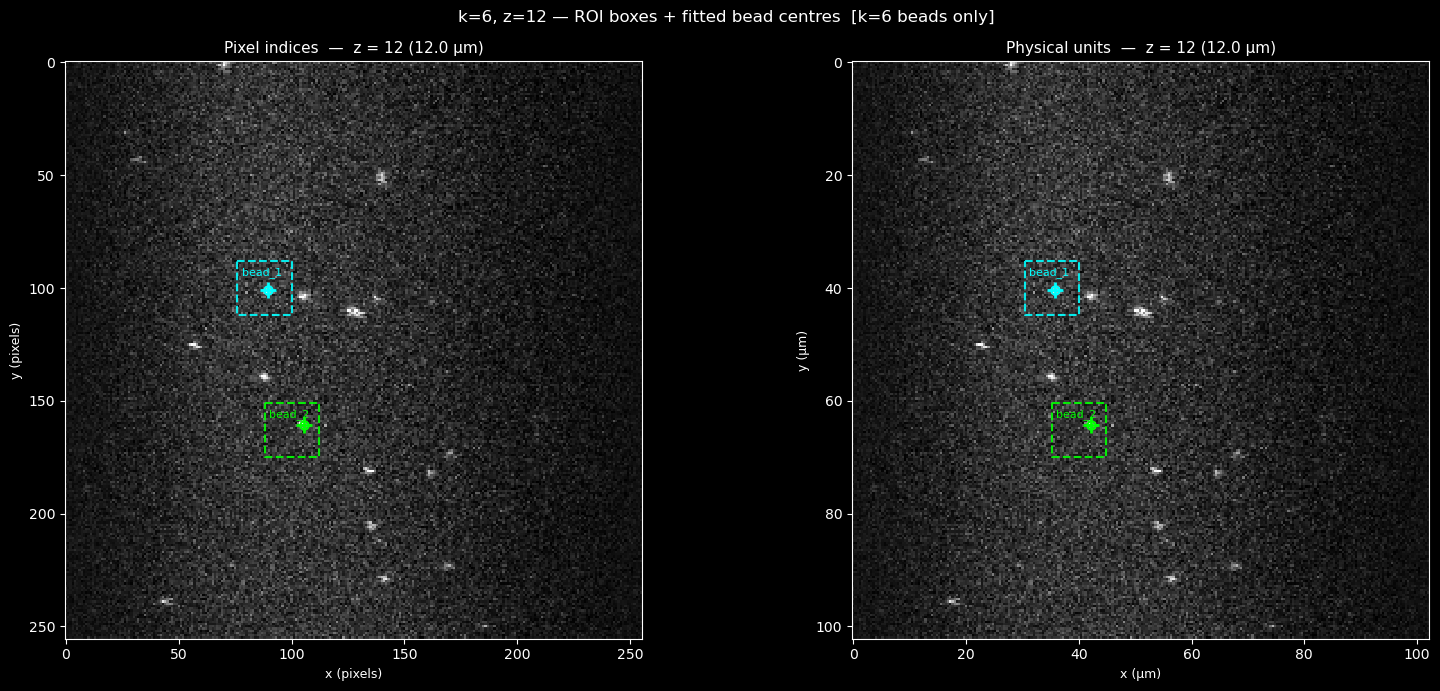

  Display z plane for k=8: z_idx=9 (9.0 µm)


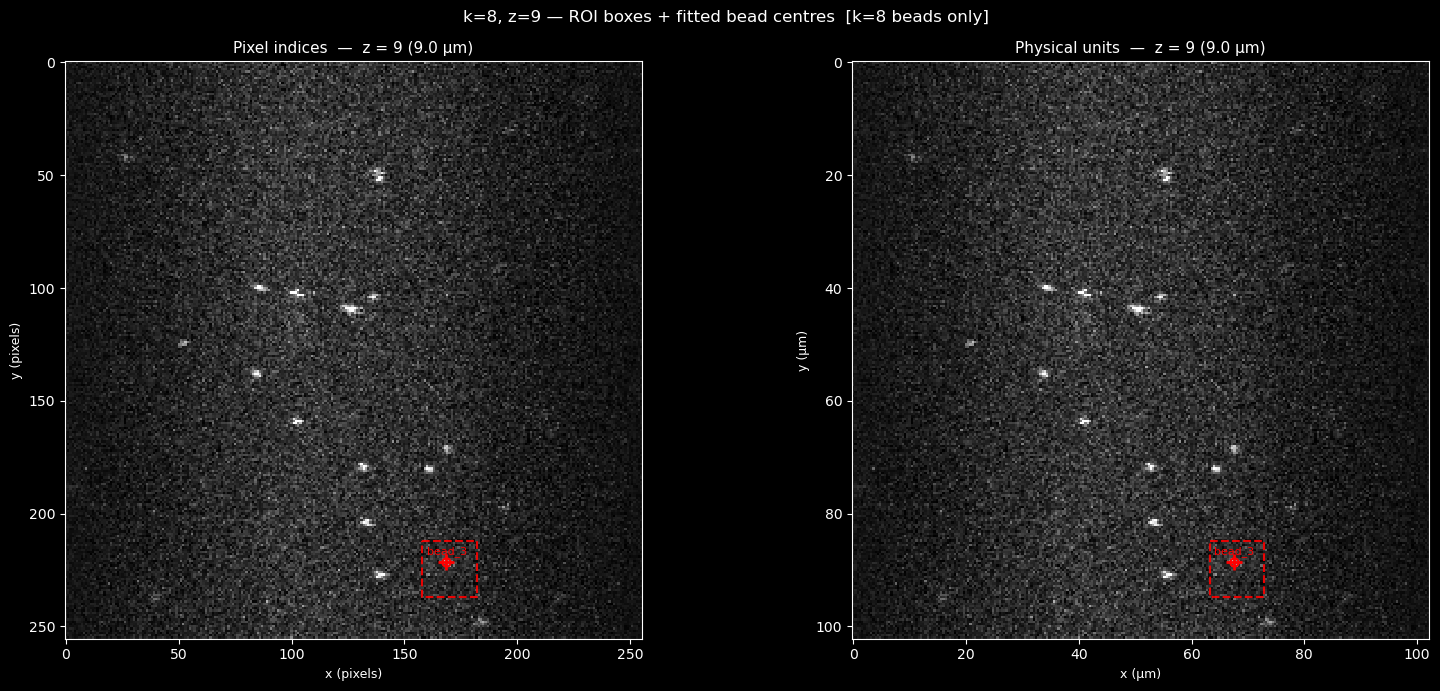

In [22]:
import numpy as np
import matplotlib.pyplot as plt

# ══════════════════════════════════════════════════════════════════════════════
# EDIT THESE
# ══════════════════════════════════════════════════════════════════════════════
k_main     = 6
k_bead3    = 8
xy_spacing = 0.4
z_spacing  = 1.0
# beads dict must already have xs_px, ys_px, best_zi_abs populated by ridge-fit
# ══════════════════════════════════════════════════════════════════════════════

colors = ['cyan', 'lime', 'red', 'yellow', 'magenta']

def get_best_z_for_k(k_val):
    """Use the brightest z plane among beads belonging to this k."""
    zi_vals = [bead['best_zi_abs'] for bead in beads.values()
               if bead.get('k') == k_val and 'best_zi_abs' in bead]
    if zi_vals:
        return int(np.round(np.mean(zi_vals)))
    return 11  # fallback

def make_roi_plot(k_display, beads_to_plot, title_suffix=''):
    z_idx = get_best_z_for_k(k_display)
    print(f"  Display z plane for k={k_display}: z_idx={z_idx} ({z_idx*z_spacing:.1f} µm)")

    nz, ny, nx = stack[k_display].shape
    vmin, vmax = np.percentile(stack[k_display], 1), np.percentile(stack[k_display], 99.99)

    fig, axes = plt.subplots(1, 2, figsize=(16, 7), facecolor='black')

    # ── Left: pixel indices ───────────────────────────────────────────────────
    ax = axes[0]
    ax.pcolormesh(np.arange(nx), np.arange(ny), stack[k_display, z_idx, :, :],
                  cmap='gray', vmin=vmin, vmax=vmax)
    ax.invert_yaxis()
    ax.set_aspect('equal')
    ax.set_facecolor('black')
    ax.tick_params(colors='white')
    ax.set_xlabel('x (pixels)', color='white', fontsize=9)
    ax.set_ylabel('y (pixels)', color='white', fontsize=9)
    ax.set_title(f'Pixel indices  —  z = {z_idx} ({z_idx*z_spacing:.1f} µm)', color='white', fontsize=11)
    for sp in ax.spines.values(): sp.set_edgecolor('white')

    for (name, bead, color) in beads_to_plot:
        x0, x1, y0, y1 = bead['roi']
        ax.plot([x0, x1, x1, x0, x0], [y0, y0, y1, y1, y0],
                color=color, lw=1.5, ls='--', alpha=0.9)
        ax.annotate(name, (x0, y0), color=color, fontsize=8,
                    xytext=(3, -10), textcoords='offset points')
        if 'xs_px' in bead:
            cx = bead['xs_px'][z_idx]
            cy = bead['ys_px'][z_idx]
            ax.plot(cx, cy, '+', color=color, ms=12, mew=2, zorder=10)
            ax.plot(cx, cy, 'o', color=color, ms=6, mew=1.5,
                    fillstyle='none', zorder=10)

    # ── Right: physical units ─────────────────────────────────────────────────
    ax = axes[1]
    ax.pcolormesh(np.arange(nx) * xy_spacing, np.arange(ny) * xy_spacing,
                  stack[k_display, z_idx, :, :],
                  cmap='gray', vmin=vmin, vmax=vmax)
    ax.invert_yaxis()
    ax.set_aspect('equal')
    ax.set_facecolor('black')
    ax.tick_params(colors='white')
    ax.set_xlabel('x (µm)', color='white', fontsize=9)
    ax.set_ylabel('y (µm)', color='white', fontsize=9)
    ax.set_title(f'Physical units  —  z = {z_idx} ({z_idx*z_spacing:.1f} µm)', color='white', fontsize=11)
    for sp in ax.spines.values(): sp.set_edgecolor('white')

    for (name, bead, color) in beads_to_plot:
        x0, x1, y0, y1 = bead['roi']
        ax.plot([x0*xy_spacing, x1*xy_spacing, x1*xy_spacing,
                 x0*xy_spacing, x0*xy_spacing],
                [y0*xy_spacing, y0*xy_spacing, y1*xy_spacing,
                 y1*xy_spacing, y0*xy_spacing],
                color=color, lw=1.5, ls='--', alpha=0.9)
        ax.annotate(name, (x0*xy_spacing, y0*xy_spacing), color=color, fontsize=8,
                    xytext=(3, -10), textcoords='offset points')
        if 'xs_px' in bead:
            cx_um = bead['xs_px'][z_idx] * xy_spacing
            cy_um = bead['ys_px'][z_idx] * xy_spacing
            ax.plot(cx_um, cy_um, '+', color=color, ms=12, mew=2, zorder=10)
            ax.plot(cx_um, cy_um, 'o', color=color, ms=6, mew=1.5,
                    fillstyle='none', zorder=10)

    fig.suptitle(f'k={k_display}, z={z_idx} — ROI boxes + fitted bead centres{title_suffix}',
                 color='white', fontsize=12)
    plt.tight_layout()
    plt.show()

# ── Print fitted centre positions ─────────────────────────────────────────────
print(f"Fitted bead centres at brightest z plane:")
print(f"{'Bead':<12} {'k':>4}  {'z_best':>6}  {'x (px)':>8}  {'y (px)':>8}  {'x (µm)':>8}  {'y (µm)':>8}")
print("-" * 68)
for (name, bead), color in zip(beads.items(), colors):
    if 'xs_px' in bead:
        zi = bead.get('best_zi_abs', 11)
        cx = bead['xs_px'][zi]
        cy = bead['ys_px'][zi]
        print(f"{name:<12} {bead['k']:>4}  {zi:>6}  {cx:>8.2f}  {cy:>8.2f}  "
              f"{cx*xy_spacing:>8.3f}  {cy*xy_spacing:>8.3f}")
    else:
        print(f"{name:<12} {bead.get('k','?'):>4}  {'no fit':>8}")

# ── Plot 1: k=6 beads ────────────────────────────────────────────────────────
beads_k6 = [(name, bead, color)
            for (name, bead), color in zip(beads.items(), colors)
            if bead.get('k') == k_main]
make_roi_plot(k_main, beads_k6, title_suffix=f'  [k={k_main} beads only]')

# ── Plot 2: k=8 bead ─────────────────────────────────────────────────────────
beads_k8 = [(name, bead, color)
            for (name, bead), color in zip(beads.items(), colors)
            if bead.get('k') == k_bead3]
make_roi_plot(k_bead3, beads_k8, title_suffix=f'  [k={k_bead3} beads only]')